In [1]:
import librosa
import os
from glob import glob
import numpy as np
data_path=r"C:\Users\User\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1"
train_data=[]
test_data=[]
for actor in os.listdir(data_path):
    if actor.startswith("Actor"):
     actor_num=int(actor.split("_")[1])
     actor_path=os.path.join(data_path,actor,"*.wav")
     file=glob(actor_path)
     if actor_num<=20:
        train_data.extend(file)
     else:
        test_data.extend(file)
print("length of train data",len(train_data))
print("length of test_data",len(test_data))


length of train data 1200
length of test_data 240


In [2]:
X=[]
Y=[]
def extract_features(data):
    for file in data:
        y,sr=librosa.load(file)
        mfcc=librosa.feature.mfcc(y=y,sr=sr,n_mfcc=40)
        mfcc=np.mean(mfcc.T,axis=0)
        emotion=int(os.path.basename(file).split('-')[2])-1
        X.append(mfcc)
        Y.append(emotion) 
    return np.array(X),np.array(Y)
    
X_train,Y_train=extract_features(train_data)
X_test,Y_test=extract_features(test_data)
np.save("X_test.npy", X_test)

c:\Users\User\Desktop\ZenithView\ai_engine\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
print("Final X_train shape:", X_train.shape)

Final X_train shape: (1200, 40, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

def build_refined_audio_model():
    model = models.Sequential([
        # Block 1
        layers.Conv1D(64, kernel_size=5, activation='relu', padding='same', input_shape=(40, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),

        # Block 2
        layers.Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Block 3
        layers.Conv1D(256, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(), # Better than Flatten for audio features
        
        # Dense Head
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(8, activation='softmax') 
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy', # Use sparse if Y is not one-hot encoded
        metrics=['accuracy']
    )
    return model

audio_model = build_refined_audio_model()

checkpoint = ModelCheckpoint('ZenithView_Audio_Best.keras', monitor='val_accuracy', save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# THE MODEL FIT
history_audio = audio_model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=100, 
    batch_size=32,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.2283 - loss: 2.8104 - val_accuracy: 0.1215 - val_loss: 2.6473 - learning_rate: 0.0010
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2567 - loss: 2.5769 - val_accuracy: 0.1340 - val_loss: 2.4236 - learning_rate: 0.0010
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2683 - loss: 2.3411 - val_accuracy: 0.1729 - val_loss: 2.0914 - learning_rate: 0.0010
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2942 - loss: 2.2010 - val_accuracy: 0.2306 - val_loss: 1.9914 - learning_rate: 0.0010
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3258 - loss: 2.0376 - val_accuracy: 0.3833 - val_loss: 1.7687 - learning_rate: 0.0010
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3075 - loss: 2.0266 - val_accuracy: 0.3792 - val_loss: 1.6803 - learning_rate: 0.0010
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3225 - loss: 2.0153 - 

In [9]:
audio_model.save('Audio_updated.keras')

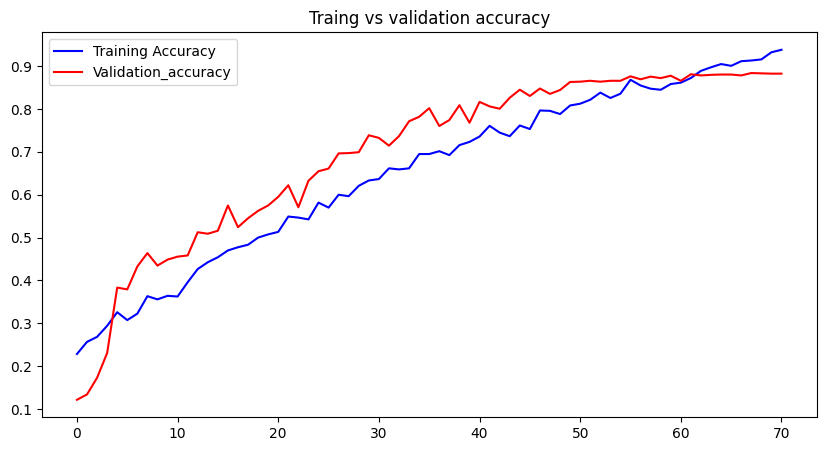

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(history_audio.history['accuracy'],color='blue',label='Training Accuracy')
plt.plot(history_audio.history['val_accuracy'],color='red',label='Validation_accuracy')
plt.title('Traing vs validation accuracy')
plt.legend()
plt.show()

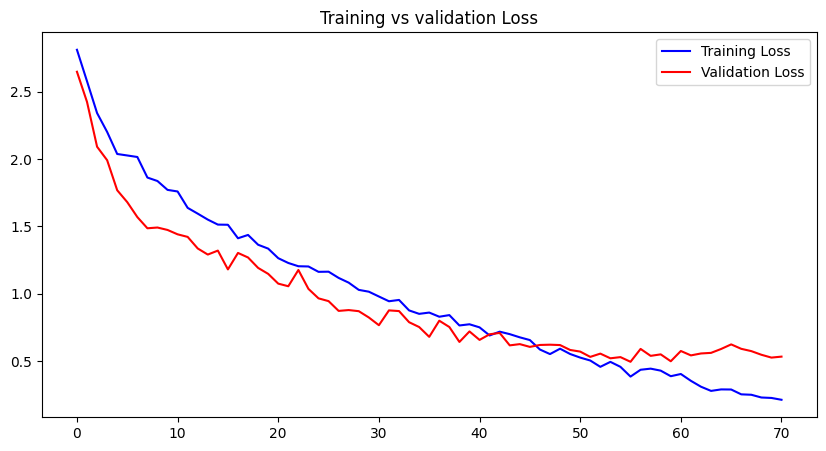

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(history_audio.history['loss'],color='blue',label="Training Loss")
plt.plot(history_audio.history['val_loss'],color='red',label="Validation Loss")
plt.title('Training vs validation Loss')
plt.legend()
plt.show()

In [4]:
from tensorflow.keras.models import load_model
model=load_model('Audio_updated.keras')

In [6]:
y_pred=model.predict(X_test)
y_pred=np.argmax(y_pred,axis=1)

 

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [7]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.84      0.89        96
           1       0.95      0.86      0.90       192
           2       0.80      0.80      0.80       192
           3       0.93      0.84      0.89       192
           4       0.83      0.97      0.89       192
           5       0.90      0.87      0.89       192
           6       0.84      0.86      0.85       192
           7       0.87      0.94      0.91       192

    accuracy                           0.88      1440
   macro avg       0.88      0.87      0.88      1440
weighted avg       0.88      0.88      0.88      1440



45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


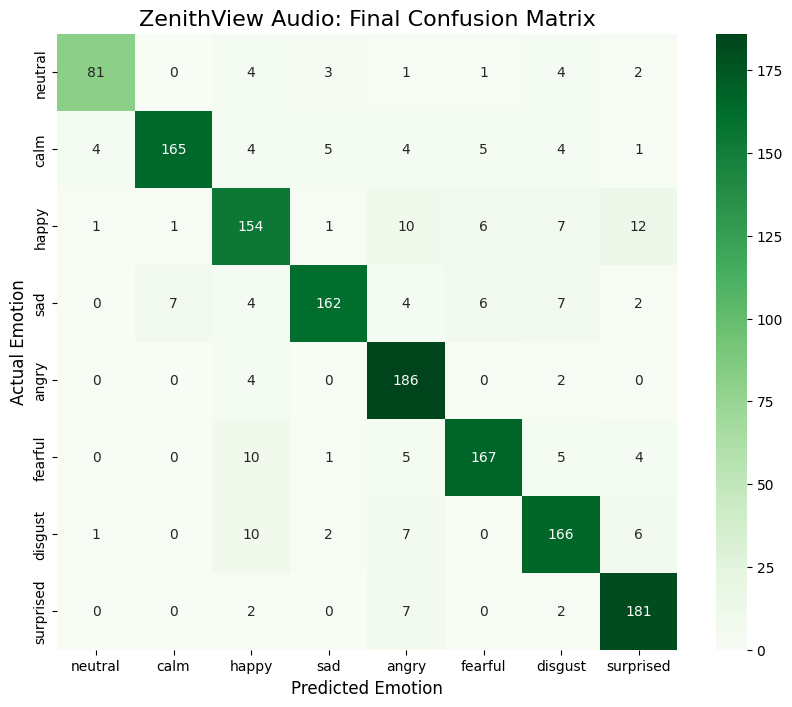

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
if len(Y_test.shape) > 1:
    y_true = np.argmax(Y_test, axis=1)
else:
    y_true = Y_test

class_labels = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, 
            yticklabels=class_labels)

plt.title('ZenithView Audio: Final Confusion Matrix', fontsize=16)
plt.ylabel('Actual Emotion', fontsize=12)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.show()

In [9]:
model.save('Audio.keras')